In [ ]:
import pandas as pd
import random

In [5]:
df = pd.DataFrame()

# create 20 more samples with random ABR genes and sources
sources = ["animal", "plant", "human", "soil", "water"]
ABR_genes = [
    "blaTEM",
    "tetM",
    "ermB",
    "sul1",
    "qnrS",
    "aac(6')-Ib",
    "mcr-1",
    "vanA",
    "blaCTX-M",
    "blaKPC",
]
for i in range(6, 26):
    sample_id = i
    source = random.choice(sources)
    ABR_gene = random.choice(ABR_genes)
    # use concat instead of append to add the new row to the dataframe
    new_row = pd.DataFrame(
        {"sample_id": [sample_id], "source": [source], "ABR_gene": [ABR_gene]}
    )
    df = pd.concat([df, new_row], ignore_index=True)
print(df)

    sample_id  source    ABR_gene
0           6   human        qnrS
1           7  animal        vanA
2           8   water      blaTEM
3           9  animal      blaKPC
4          10   plant      blaKPC
5          11   human    blaCTX-M
6          12    soil      blaKPC
7          13    soil      blaKPC
8          14   plant        ermB
9          15  animal       mcr-1
10         16   human    blaCTX-M
11         17    soil       mcr-1
12         18   water  aac(6')-Ib
13         19  animal      blaTEM
14         20   water      blaKPC
15         21   plant    blaCTX-M
16         22   human        qnrS
17         23   water        qnrS
18         24    soil        tetM
19         25  animal        vanA


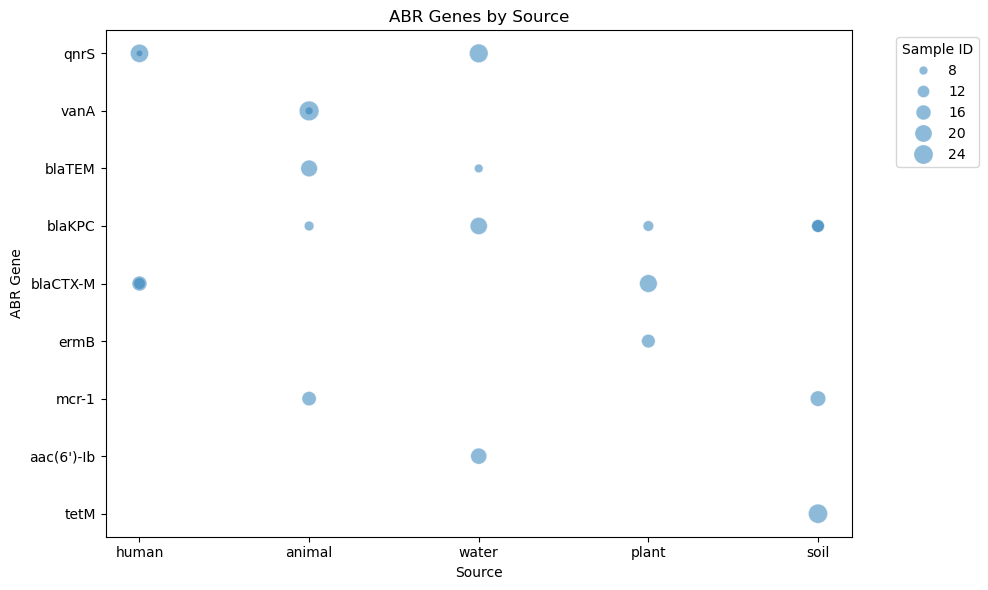

In [6]:
# generate a bubble plot of ABR genes by source
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x="source", y="ABR_gene", size="sample_id", sizes=(20, 200), alpha=0.5
)
plt.title("ABR Genes by Source")
plt.xlabel("Source")
plt.ylabel("ABR Gene")
plt.legend(title="Sample ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
# Can you do the same with a packed bubble plot, using patplotlib only ?
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[: len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[: len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3])

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0], bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = self.bubbles[i, :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i, :2] - orth * self.step_dist
                        dist1 = self.center_distance(self.com, np.array([new_point1]))
                        dist2 = self.center_distance(self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(
                *self.bubbles[i, :2],
                labels[i],
                horizontalalignment="center",
                verticalalignment="center",
            )

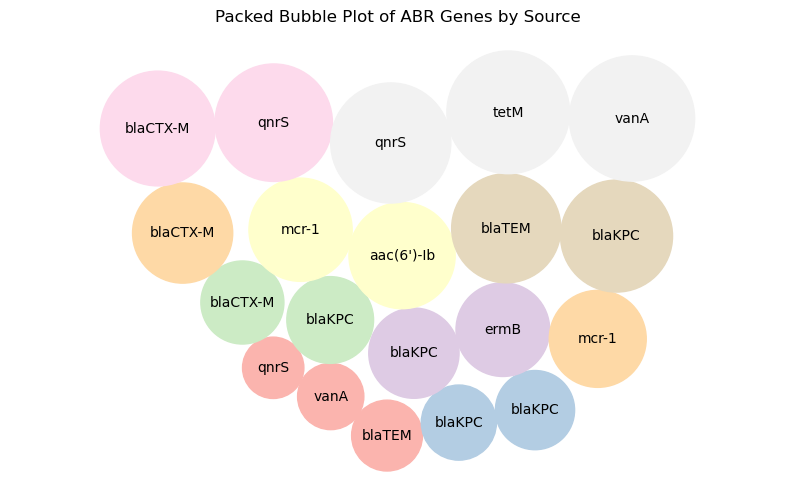

In [14]:
# use the BubbleChart class to create a packed bubble plot of ABR genes by source
area = df["sample_id"]  # use sample_id as area for the bubbles
labels = df["ABR_gene"]  # use ABR_gene as labels for the bubbles
# use pastel colors for the bubbles using a color map
colors = plt.cm.Pastel1(np.linspace(0, 1, len(df)))

bubble_chart = BubbleChart(area)
bubble_chart.collapse()
fig, ax = plt.subplots(figsize=(10, 6))
bubble_chart.plot(ax, labels, colors)
plt.title("Packed Bubble Plot of ABR Genes by Source")
plt.axis("equal")
plt.axis("off")
plt.show()